In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_FILE = ROOT / "data" / "raw" / "ASR_Fairness_Master_Spreadsheet_v5_descriptives.xlsx"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_FILE, sheet_name="master_data")
df = df[df["eligible_for_main_analysis"] == True].copy()
df = df[df["wer_reported"].notna()].copy()

df["resource_level_tertile"] = df["resource_level_tertile"].astype(str).str.strip().str.title()
df["transcript_type_binary"] = df["transcript_type_binary"].astype(str).str.strip()

df.head()

,row_id,source_id,source_citation_short,extraction_status,notes_general,asr_model_name_raw,asr_model_name_standardized,benchmark_name_raw,benchmark_name_standardized,source_paper_name,...,recording_condition_notes,evaluation_split,dataset_condition_notes,has_performance_metric,has_training_hours,has_transcript_type,eligible_for_main_analysis,exclusion_reason,ambiguity_flag,verification_flag
1,OBS002,SRC01,"Radford et al., 2022",extracted,Whisper paper Table 8; evaluated on MLS test s...,Whisper large-v2,Whisper large-v2,Multilingual LibriSpeech,MLS,Robust Speech Recognition Via Large-Scale Weak...,...,NaN,test,NaN,True,True,True,True,NaN,False,verified
2,OBS003,SRC01,"Radford et al., 2022",extracted,Whisper paper Table 8; evaluated on MLS test s...,Whisper large-v2,Whisper large-v2,Multilingual LibriSpeech,MLS,Robust Speech Recognition Via Large-Scale Weak...,...,NaN,test,NaN,True,True,True,True,NaN,False,verified
3,OBS004,SRC01,"Radford et al., 2022",extracted,Whisper paper Table 8; evaluated on MLS test s...,Whisper large-v2,Whisper large-v2,Multilingual LibriSpeech,MLS,Robust Speech Recognition Via Large-Scale Weak...,...,NaN,test,NaN,True,True,True,True,NaN,False,verified
6,OBS007,SRC01,"Radford et al., 2022",extracted,Whisper paper Table 8; evaluated on MLS test s...,Whisper large-v2,Whisper large-v2,Multilingual LibriSpeech,MLS,Robust Speech Recognition Via Large-Scale Weak...,...,NaN,test,NaN,True,True,True,True,NaN,False,verified
7,OBS008,SRC01,"Radford et al., 2022",extracted,Whisper paper Table 8; evaluated on MLS test s...,Whisper large-v2,Whisper large-v2,Multilingual LibriSpeech,MLS,Robust Speech Recognition Via Large-Scale Weak...,...,NaN,test,NaN,True,True,True,True,NaN,False,verified


/var/folders/y6/rf8l104j5t5g9zn93s3jfn3c0000gn/T/ipykernel_12239/2533705188.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=resource_order)


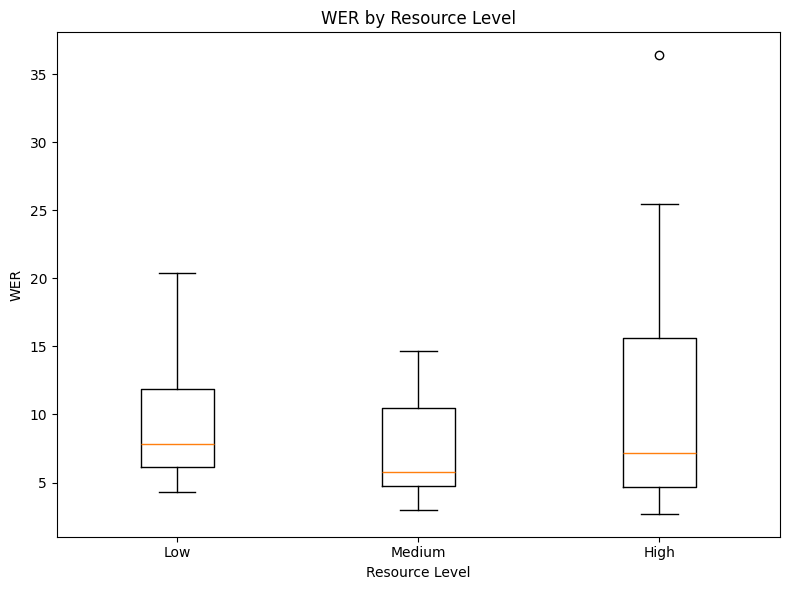

In [3]:
resource_order = ["Low", "Medium", "High"]
plot_df = df[df["resource_level_tertile"].isin(resource_order)].copy()

plt.figure(figsize=(8, 6))
groups = [plot_df.loc[plot_df["resource_level_tertile"] == lvl, "wer_reported"] for lvl in resource_order]
plt.boxplot(groups, labels=resource_order)
plt.title("WER by Resource Level")
plt.xlabel("Resource Level")
plt.ylabel("WER")
plt.tight_layout()
plt.savefig(FIG_DIR / "filename.png", dpi=300)
plt.show()

/var/folders/y6/rf8l104j5t5g9zn93s3jfn3c0000gn/T/ipykernel_12239/2981469717.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=reference_order)


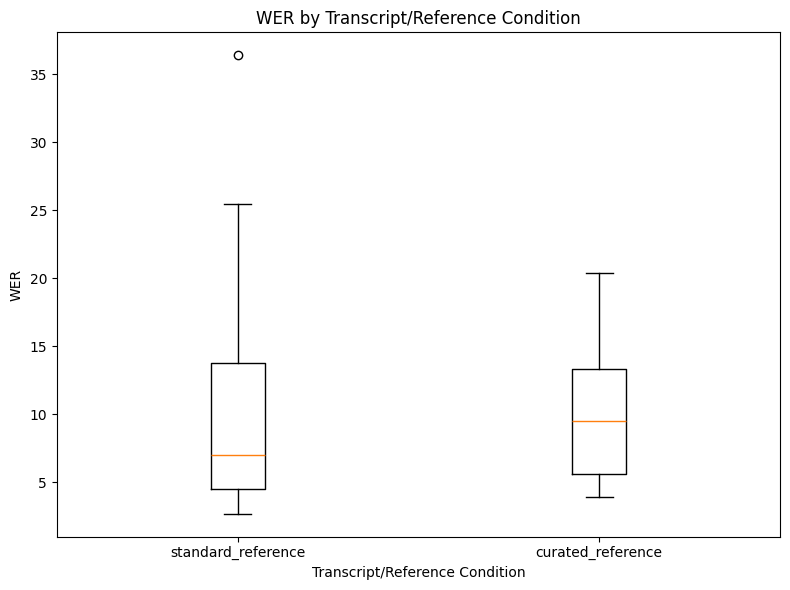

In [4]:
reference_order = ["standard_reference", "curated_reference"]
plot_df = df[df["transcript_type_binary"].isin(reference_order)].copy()

plt.figure(figsize=(8, 6))
groups = [plot_df.loc[plot_df["transcript_type_binary"] == cond, "wer_reported"] for cond in reference_order]
plt.boxplot(groups, labels=reference_order)
plt.title("WER by Transcript/Reference Condition")
plt.xlabel("Transcript/Reference Condition")
plt.ylabel("WER")
plt.tight_layout()
plt.savefig(FIG_DIR / "filename.png", dpi=300)
plt.show()

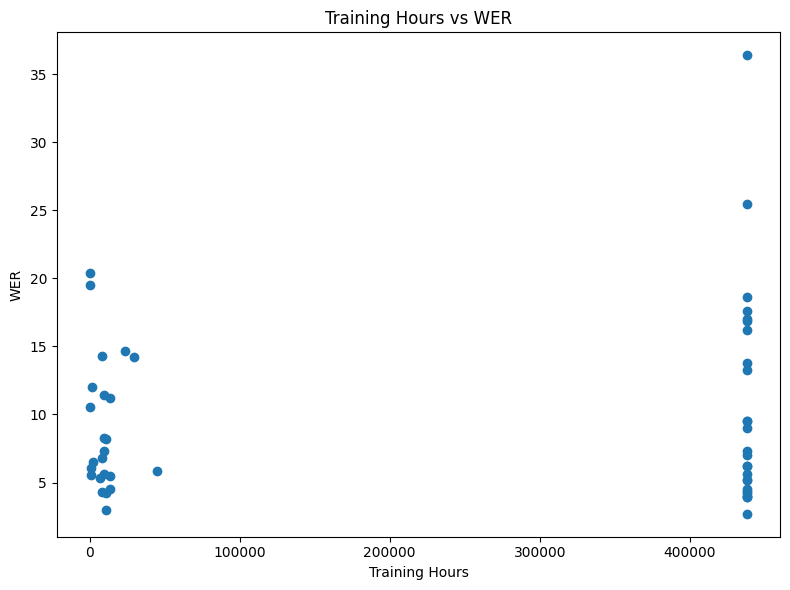

In [5]:
plot_df = df[df["training_hours_numeric"].notna()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["training_hours_numeric"], plot_df["wer_reported"])
plt.title("Training Hours vs WER")
plt.xlabel("Training Hours")
plt.ylabel("WER")
plt.tight_layout()
plt.savefig(FIG_DIR / "filename.png", dpi=300)
plt.show()